### checking the signal linearity to ND filter and boxcar sensitivity

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from PyQt6.QtWidgets import QApplication, QFileDialog

def select_folder_pyqt6():
    # Create application
    app = QApplication(sys.argv)

    # Open folder dialog
    folder_path = QFileDialog.getExistingDirectory(
        None,
        "Select a folder",
        ""
    )

    # Close QApplication
    app.exit()

    return folder_path

In [3]:
path_ref = select_folder_pyqt6()
path_main = select_folder_pyqt6()


In [4]:
from shg_analysis import SHGDataAnalysis
from crystaldatabase import CRYSTALS
from crystaldatabase import *

analysis_ref = SHGDataAnalysis(path_ref)
meta_ref = analysis_ref.meta
data_ref = analysis_ref.data

analysis_main = SHGDataAnalysis(path_main)
meta_main = analysis_main.meta
data_main = analysis_main.data

Scale k = 1.008491
RMS residual = 0.0321774
Scale accuracy: 10.084909615848598


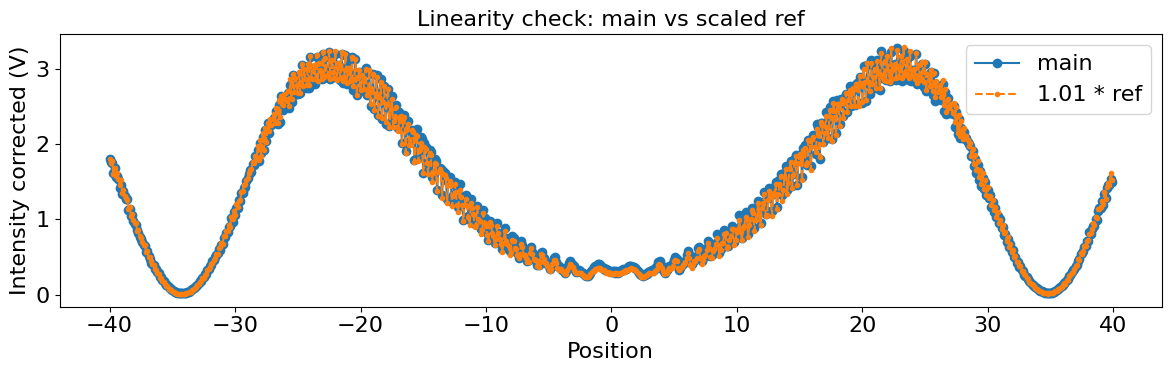

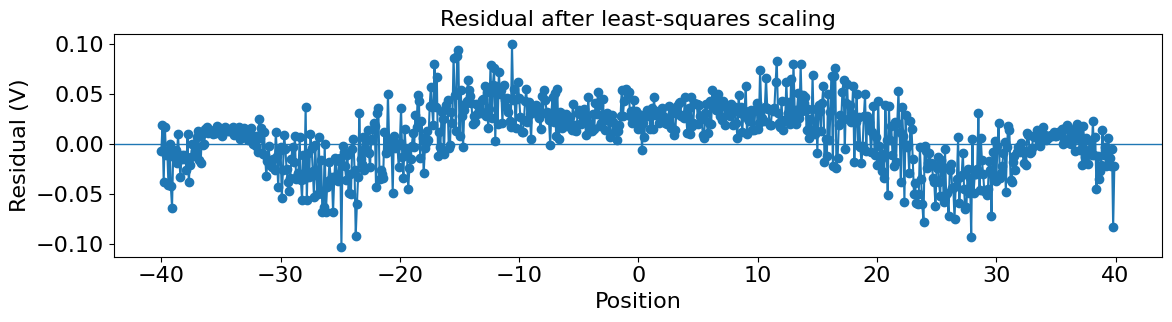

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Plot style control (single variable) ----
ft = 16  # Change this to scale everything

plt.rcParams.update({
    "font.size": ft,
    "axes.titlesize": ft,
    "axes.labelsize": ft,
    "xtick.labelsize": ft,
    "ytick.labelsize": ft,
    "legend.fontsize": ft,
})

# ---- Extract x and y ----
# Try common keys. Adjust here if your SHGDataAnalysis uses different names.
x_ref = np.asarray(data_ref.get("position"))
y_ref = np.asarray(data_ref["intensity_corrected"])

x_main = np.asarray(data_main.get("position"))
y_main = np.asarray(data_main["intensity_corrected"])

# ---- Safety checks ----
if x_ref is None or x_main is None:
    raise KeyError("x array not found. Expected 'position_centered' or 'position' in data_ref/data_main.")
if y_ref is None or y_main is None:
    raise KeyError("'intensity_corrected' not found in data_ref/data_main.")

# Ensure 1D
x_ref = np.ravel(x_ref); y_ref = np.ravel(y_ref)
x_main = np.ravel(x_main); y_main = np.ravel(y_main)

# Sort ref for interpolation
idx_sort = np.argsort(x_ref)
x_ref_s = x_ref[idx_sort]
y_ref_s = y_ref[idx_sort]

# Interpolate ref onto main x-grid (outside range -> NaN)
y_ref_on_main = np.interp(x_main, x_ref_s, y_ref_s, left=np.nan, right=np.nan)

# ---- Least squares for k: minimize ||y_main - k*y_ref_on_main||^2 ----
mask = np.isfinite(y_main) & np.isfinite(y_ref_on_main)

if np.sum(mask) < 3:
    raise RuntimeError("Not enough overlapping finite points between main and ref after interpolation.")

a = y_ref_on_main[mask]
b = y_main[mask]

den = np.dot(a, a)
if den == 0:
    raise RuntimeError("Denominator is zero (ref signal is all zeros over the overlap). Cannot fit k.")

k = np.dot(a, b) / den
residual = y_main - k * y_ref_on_main

print(f"Scale k = {k:.8g}")
print(f"RMS residual = {np.sqrt(np.mean(residual[mask]**2)):.6g}")
print(f"Scale accuracy: {k/0.10}")

# ---- Plot: overlay ----
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_main, y_main, marker="o", linestyle="-", label="main")
ax.plot(x_main, k * y_ref_on_main, marker=".", linestyle="--", label=f"{k:.3g} * ref")
ax.set_xlabel("Position")
ax.set_ylabel("Intensity corrected (V)")
ax.set_title("Linearity check: main vs scaled ref")
ax.legend()
fig.tight_layout()
plt.show()

# ---- Plot: residual ----
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x_main, residual, marker="o", linestyle="-", label=f"residual = main - {k:.3g}*ref")
ax.axhline(0, linewidth=1)
ax.set_xlabel("Position")
ax.set_ylabel("Residual (V)")
ax.set_title("Residual after least-squares scaling")
# ax.legend()
fig.tight_layout()
plt.show()


In [6]:
print(f"path_ref: {path_ref}")
print(f"path_main: {path_main}")

path_ref: X:/Anlagen/_lab31316-nlo/Inbox/experiment/202511_NLO_measurement_results/20260218_1133_quartz-1_d11_rotation
path_main: X:/Anlagen/_lab31316-nlo/Inbox/experiment/202511_NLO_measurement_results/20260218_1144_quartz-1_d11_rotation
